# Analysis of Qubit Properties

In [40]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
def parse_umm(s):
    if isinstance(s, str):
        return float(s.replace('um', '').strip())
    return float(s)

data_dir = '.'
all_data = []

for filename in os.listdir(data_dir):
    if filename.endswith('_data.csv'):
        filepath = os.path.join(data_dir, filename)
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()
        
        # Extract parameters from filename
        match = re.search(r'pad_width_(\d+)_(\d+)_pad_height_(\d+)_pad_gap_(\d+)_data.csv', filename)
        if match:
            pad_height_file = int(match.group(3))
            pad_gap_file = int(match.group(4))
        else:
            # Fallback if regex doesn't match
            pad_height_file = -1
            pad_gap_file = -1

        df['pad_height_file'] = pad_height_file
        df['pad_gap_file'] = pad_gap_file
        
        all_data.append(df)

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Clean data
    for col in ['pad_gap', 'pad_width', 'pad_height']:
        if col in combined_df.columns:
            combined_df[col] = combined_df[col].apply(parse_umm)
            
    # Convert columns to numeric, coercing errors
    for col in ['fQ', 'alpha', 'EC', 'EJ', 'dispersion']:
        combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # Drop rows with NaNs in key columns
    combined_df.dropna(subset=['fQ', 'alpha', 'EC', 'EJ', 'dispersion', 'pad_width', 'pad_height', 'pad_gap'], inplace=True)
    
    combined_df['EJ/EC ratio'] = 1000 * combined_df['EJ'] / combined_df['EC']
    combined_df['pad_width/pad_height ratio'] = combined_df['pad_width'] / combined_df['pad_height']

    print(combined_df.info())
    print(combined_df.head())
else:
    print('No CSV files found.')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Iteration                   210 non-null    int64  
 1   pad_gap                     210 non-null    float64
 2   pad_width                   210 non-null    float64
 3   pad_height                  210 non-null    float64
 4   cap_matrix                  210 non-null    object 
 5   fQ                          210 non-null    float64
 6   EC                          210 non-null    float64
 7   EJ                          210 non-null    float64
 8   alpha                       210 non-null    float64
 9   dispersion                  210 non-null    float64
 10  gbus                        210 non-null    object 
 11  chi_in_MHz                  210 non-null    object 
 12  cap_matrix_all_passes       210 non-null    object 
 13  lom_all_passes              210 non

## Plotting

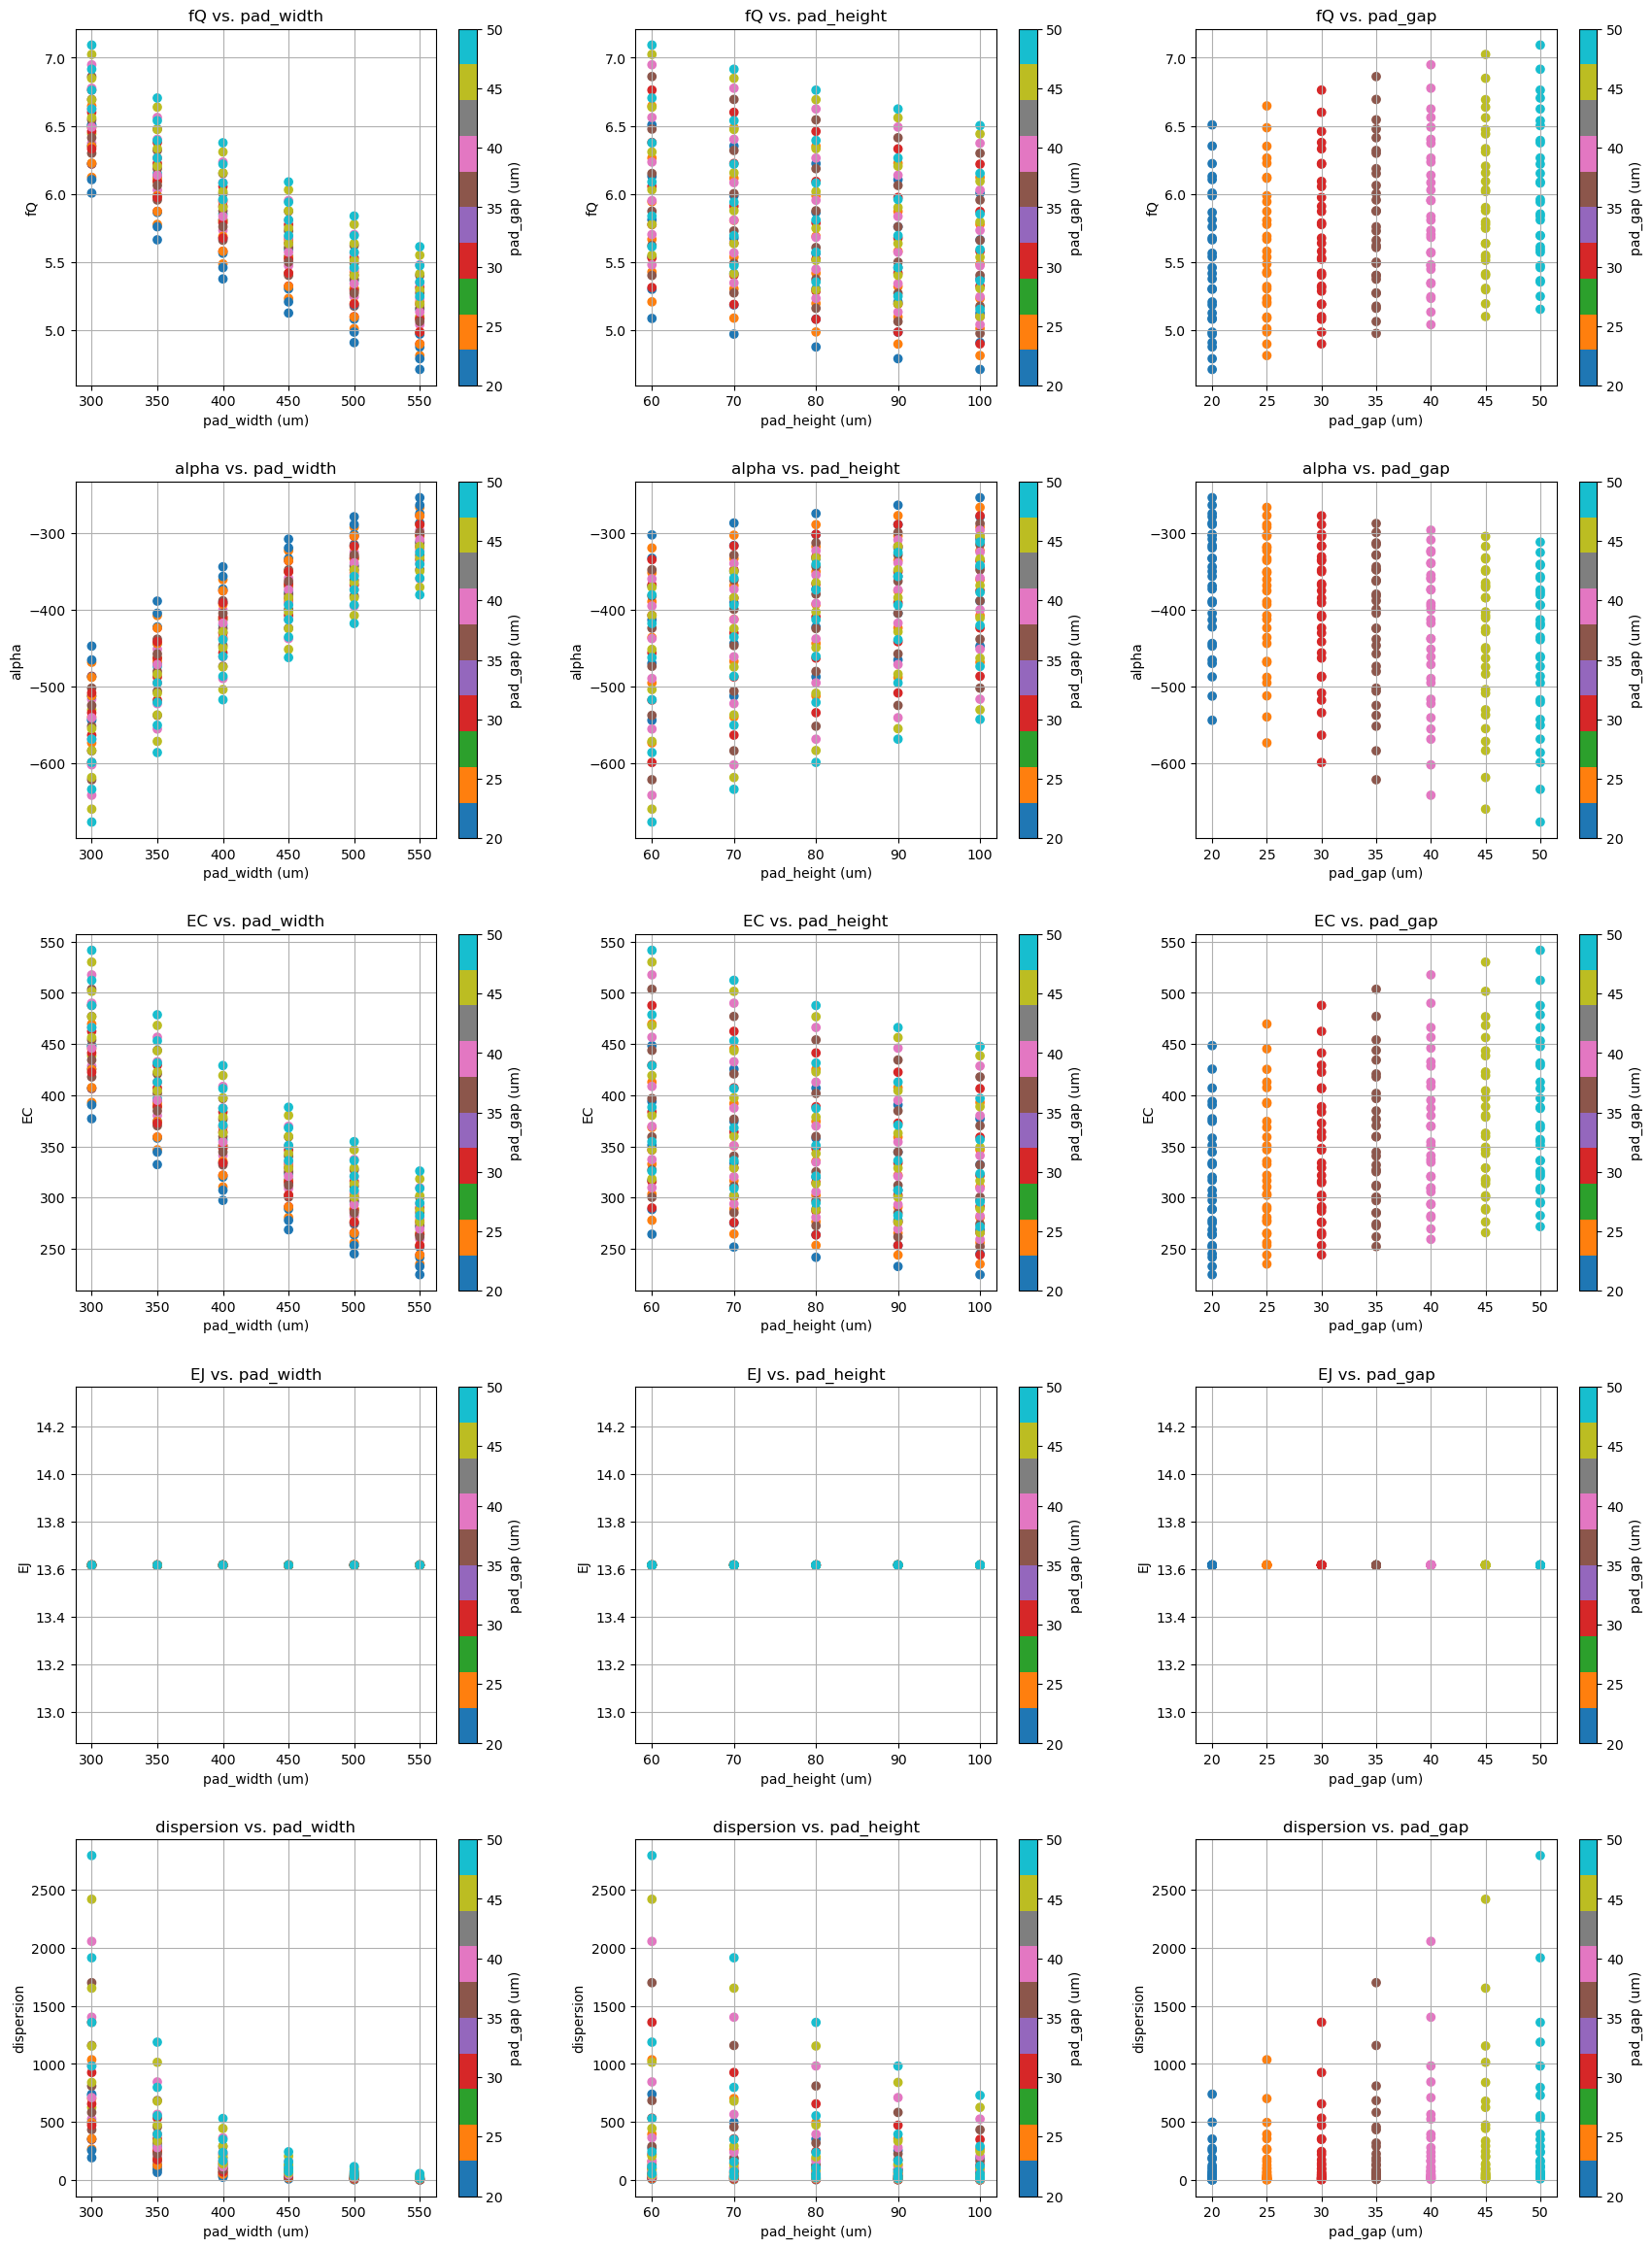

In [42]:
if 'combined_df' in locals() and not combined_df.empty:
    properties = ['fQ', 'alpha', 'EC', 'EJ', 'dispersion']
    parameters = ['pad_width', 'pad_height', 'pad_gap']
    
    fig, axes = plt.subplots(len(properties), len(parameters), figsize=(18, 24))
    fig.tight_layout(pad=5.0)

    for i, prop in enumerate(properties):
        for j, param in enumerate(parameters):
            ax = axes[i, j]
            
            # Use a colormap for coloring
            scatter = ax.scatter(combined_df[param], combined_df[prop], c=combined_df['pad_gap'], cmap='tab10')
            
            ax.set_title(f'{prop} vs. {param}')
            ax.set_xlabel(f'{param} (um)')
            ax.set_ylabel(prop)
            ax.grid(True)
            
            # Add a colorbar to each subplot
            cbar = fig.colorbar(scatter, ax=ax)
            cbar.set_label('pad_gap (um)')

    plt.show()
else:
    print('DataFrame is empty, cannot plot.')

## EJ/EC Ratio vs. Pad Ratio

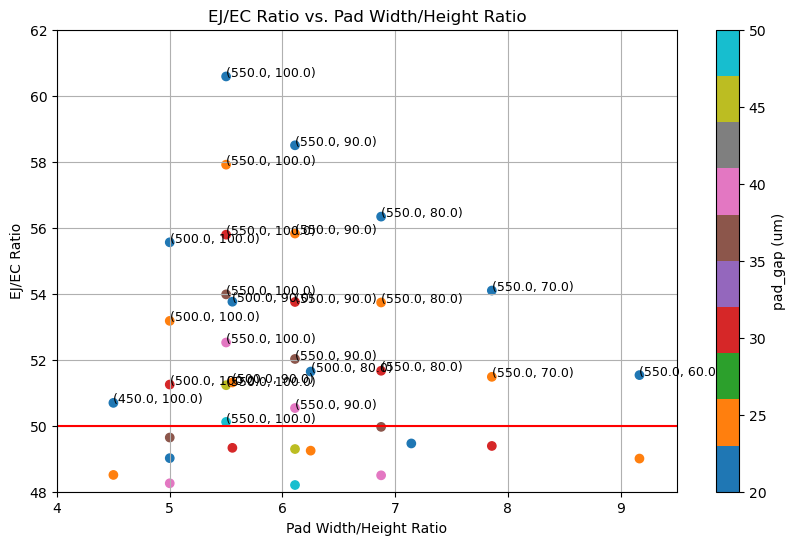

In [43]:
if 'combined_df' in locals() and not combined_df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(combined_df['pad_width/pad_height ratio'], combined_df['EJ/EC ratio'], c=combined_df['pad_gap'], cmap='tab10')

    for index, row in combined_df.iterrows():
        if row['EJ/EC ratio'] > 50:
            ax.text(row['pad_width/pad_height ratio'], row['EJ/EC ratio'], f"({row['pad_width']}, {row['pad_height']})", fontsize=9)

    ax.hlines(y=50, xmin=2.5, xmax=9.5, colors='red')
    ax.set_xlim(4, 9.5)
    ax.set_ylim(48, 62)
    ax.set_title('EJ/EC Ratio vs. Pad Width/Height Ratio')
    ax.set_xlabel('Pad Width/Height Ratio')
    ax.set_ylabel('EJ/EC Ratio')
    ax.grid(True)

    cbar = fig.colorbar(scatter)
    cbar.set_label('pad_gap (um)')

    plt.show()
else:
    print('DataFrame is empty, cannot plot.')